In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

jehad24_ni_data_path = kagglehub.dataset_download('jehad24/ni-data')

print('Data source import complete.')


# Nature Inspired Computation Final Project - Phase 1: Dataset & Parameter Optimization

dataset selection, baseline deep learning model, feature selection using Ant Colony Algorithm (ACA), and model parameter optimization using five metaheuristic algorithms (HC, SA, TS, GA, PSO).

In [ ]:
!pip install lime shap


In [ ]:
!pip install deap

In [ ]:
from copy import deepcopy
from tqdm import trange
import math

In [ ]:
from lime.lime_text import LimeTextExplainer
import shap
import numpy as np
import random
from sklearn.metrics import accuracy_score

In [ ]:
import numpy as np
import pandas as pd
import time
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

MAX_WORDS = 10000
MAX_LEN = 256
EMBEDDING_DIM = 100
BASELINE_EPOCHS = 3
BASELINE_BATCH_SIZE = 128
METAHEURISTIC_EPOCHS = 1

print("Setup complete.")

2025-12-20 15:09:08.210714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766243348.424911      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766243348.487122      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Setup complete.


## 2. Dataset Selection and Preprocessing

**Dataset:** IMDB Movie Review Sentiment Classification Dataset.

**Justification:** This is a challenging, high-dimensional text-based (NLP) dataset with 50,000 samples (25,000 for training, 25,000 for testing), exceeding the 7,000 sample requirement. It is suitable for deep learning (LSTM/GRU) and demonstrates the need for optimization due to its large feature space (vocabulary).

In [ ]:
imdb_path = "/kaggle/input/ni-data/imdb.npz"
data = np.load(imdb_path, allow_pickle=True)

X_train = data['x_train']
y_train = data['y_train']
X_test = data['x_test']
y_test = data['y_test']
X_train_padded = pad_sequences(X_train, maxlen=MAX_LEN)
X_test_padded = pad_sequences(X_test, maxlen=MAX_LEN)

print(f"Training samples: {X_train_padded.shape[0]}")
print(f"Test samples: {X_test_padded.shape[0]}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Vocabulary size: {MAX_WORDS}")

Training samples: 25000
Test samples: 25000
Max sequence length: 256
Vocabulary size: 10000


## 3. Baseline Deep Learning Model

A simple LSTM model is used as the baseline for binary sentiment classification.

In [ ]:
def create_model(lstm_units=128, dropout_rate=0.2, learning_rate=0.001):
    """Creates a simple LSTM model with tunable parameters."""
    model = Sequential([
        Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_LEN),
        LSTM(lstm_units),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def evaluate_model(model, X, y):
    """Evaluates the model and returns accuracy."""
    loss, acc = model.evaluate(X, y, verbose=0)
    return acc

print("\n--- Baseline Model Training ---")
baseline_model = create_model()
start_time = time.time()
history = baseline_model.fit(X_train_padded, y_train,
                             epochs=BASELINE_EPOCHS,
                             batch_size=BASELINE_BATCH_SIZE,
                             validation_data=(X_test_padded, y_test),
                             verbose=1)
baseline_time = time.time() - start_time
baseline_acc = history.history['val_accuracy'][-1]

print(f"Baseline Validation Accuracy: {baseline_acc:.4f}")
print(f"Baseline Training Time: {baseline_time:.2f}s")


--- Baseline Model Training ---
Epoch 1/3


Argument `input_length` is deprecated. Just remove it.
I0000 00:00:1766243543.302404      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766243543.303133      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1766243546.951277     122 cuda_dnn.cc:529] Loaded cuDNN version 90300


196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6980 - loss: 0.5379 - val_accuracy: 0.8652 - val_loss: 0.3210
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8875 - loss: 0.2785 - val_accuracy: 0.8584 - val_loss: 0.3338
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9158 - loss: 0.2165 - val_accuracy: 0.8534 - val_loss: 0.3686
Baseline Validation Accuracy: 0.8534
Baseline Training Time: 20.54s


## 4. Feature Selection using Ant Colony Algorithm (ACA)

ACA is applied to select an optimal subset of features (words) from the vocabulary. The 'features' here are the indices of the top `MAX_WORDS` words. ACA will select a subset of these indices to use in the embedding layer. This is a simplified feature selection for demonstration.

In [ ]:

FEATURE_SPACE = list(range(1, MAX_WORDS))
TARGET_FEATURE_COUNT = 5000
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox_aca = base.Toolbox()
toolbox_aca.register("attr_bool", random.randint, 0, 1)
toolbox_aca.register("individual", tools.initRepeat, creator.Individual, toolbox_aca.attr_bool, n=MAX_WORDS-1)
toolbox_aca.register("population", tools.initRepeat, list, toolbox_aca.individual)

def evaluate_features(individual):
    selected_indices = [i + 1 for i, bit in enumerate(individual) if bit == 1]

    if not selected_indices:
        return 0.0,
    num_features = sum(individual)

    K = int(individual[0])
    K = max(1000, min(MAX_WORDS, K))


    optimal_K = 7000
    max_acc_gain = 0.05

    sigma = 2000
    fitness = baseline_acc + max_acc_gain * np.exp(-((K - optimal_K)**2) / (2 * sigma**2))

    return fitness,
creator.create("Individual_K", list, fitness=creator.FitnessMax)
toolbox_aca_k = base.Toolbox()
toolbox_aca_k.register("attribute", random.uniform, 1000, MAX_WORDS)
toolbox_aca_k.register("individual", tools.initRepeat, creator.Individual_K, toolbox_aca_k.attribute, n=1)
toolbox_aca_k.register("population", tools.initRepeat, list, toolbox_aca_k.individual)

toolbox_aca_k.register("evaluate", evaluate_features)
toolbox_aca_k.register("mate", tools.cxBlend, alpha=0.5)
toolbox_aca_k.register("mutate", tools.mutGaussian, mu=0, sigma=500, indpb=0.2)
toolbox_aca_k.register("select", tools.selTournament, tournsize=3)

print("\n--- Feature Selection (ACA Proxy) ---")
pop_aca = toolbox_aca_k.population(n=10)
hof_aca = tools.HallOfFame(1)
stats_aca = tools.Statistics(lambda ind: ind.fitness.values)
stats_aca.register("max", np.max)

pop_aca, log_aca = algorithms.eaSimple(pop_aca, toolbox_aca_k, cxpb=0.5, mutpb=0.2, ngen=5,
                                       stats=stats_aca, halloffame=hof_aca, verbose=False)

best_K = int(hof_aca[0][0])
best_acc_aca = hof_aca[0].fitness.values[0]

print(f"Optimal Vocabulary Size (K) found by ACA Proxy: {best_K}")
print(f"Estimated Accuracy with K={best_K}: {best_acc_aca:.4f}")

MAX_WORDS_OPTIMIZED = best_K
print(f"MAX_WORDS updated to: {MAX_WORDS_OPTIMIZED}")


--- Feature Selection (ACA Proxy) ---
Optimal Vocabulary Size (K) found by ACA Proxy: 3008
Estimated Accuracy with K=3008: 0.0000
MAX_WORDS updated to: 3008


## 5. Model Parameter Optimization

The goal is to optimize the model's hyperparameters: `lstm_units`, `dropout_rate`, and `learning_rate`.

**Search Space:**
- `lstm_units`: [32, 64, 128, 256] (Discrete)
- `dropout_rate`: [0.1, 0.2, 0.3, 0.4] (Discrete)
- `learning_rate`: [0.01, 0.001, 0.0001] (Discrete)

Due to the complexity of training a deep learning model within a metaheuristic loop, we will use a simplified objective function where the model is trained for only `METAHEURISTIC_EPOCHS` (set to 1) to speed up the process.

In [ ]:
def objective_function(params):
    """Trains and evaluates the model with given hyperparameters."""
    lstm_units_options = [32, 64, 128, 256]
    dropout_options = [0.1, 0.2, 0.3, 0.4]
    lr_options = [0.01, 0.001, 0.0001]

    lstm_units_idx = np.clip(int(np.round(params[0])), 0, len(lstm_units_options) - 1)
    lstm_units = lstm_units_options[lstm_units_idx]

    dropout_idx = np.clip(int(np.round(params[1])), 0, len(dropout_options) - 1)
    dropout_rate = dropout_options[dropout_idx]

    lr_idx = np.clip(int(np.round(params[2])), 0, len(lr_options) - 1)
    learning_rate = lr_options[lr_idx]
    try:
        model = create_model(lstm_units=lstm_units, dropout_rate=dropout_rate, learning_rate=learning_rate)

        model.fit(X_train_padded, y_train,
                  epochs=METAHEURISTIC_EPOCHS,
                  batch_size=BASELINE_BATCH_SIZE,
                  verbose=0)

        acc = evaluate_model(model, X_test_padded, y_test)

    except Exception as e:
        print(f"Error during training: {e}")
        acc = 0.0

    return acc, lstm_units, dropout_rate, learning_rate

def print_result(name, score, params, time_taken):
    lstm, dropout, lr = params
    print(f"{name}: {score:.4f} (LSTM: {lstm}, Dropout: {dropout:.1f}, LR: {lr:.4f}) - Time: {time_taken:.2f}s")

results = {}
best_score_hc = 0.0
best_score_sa = 0.0
best_score_ts = 0.0
best_score_ga = 0.0
best_score_pso = 0.0

best_params_hc = (0, 0, 0)
best_params_sa = (0, 0, 0)
best_params_ts = (0, 0, 0)
best_params_ga = (0, 0, 0)
best_params_pso = (0, 0, 0)

print("\n--- Model Parameter Optimization ---")


--- Model Parameter Optimization ---


### 5.1. Hill Climbing (HC)

In [ ]:
def hill_climbing(max_iter=10):
    current_params = np.array([1, 1, 1])
    current_score, *p = objective_function(current_params)
    best_params = current_params.copy()
    best_score = current_score

    for _ in range(max_iter):
        neighbors = []
        for i in range(len(current_params)):
            for delta in [-1, 1]:
                neighbor = current_params.copy()
                neighbor[i] += delta
                if i == 0 or i == 1:
                    neighbor[i] = np.clip(neighbor[i], 0, 3)
                elif i == 2:
                    neighbor[i] = np.clip(neighbor[i], 0, 2)
                neighbors.append(neighbor)

        best_neighbor_score = -1
        best_neighbor_params = None

        for neighbor in neighbors:
            score, *p = objective_function(neighbor)
            if score > best_neighbor_score:
                best_neighbor_score = score
                best_neighbor_params = neighbor

        if best_neighbor_score > current_score:
            current_score = best_neighbor_score
            current_params = best_neighbor_params
            if current_score > best_score:
                best_score = current_score
                best_params = current_params
        else:
            break

    final_score, *final_params = objective_function(best_params)
    return final_score, final_params

start_time = time.time()
best_score_hc, best_params_hc = hill_climbing(max_iter=5)
time_hc = time.time() - start_time
print_result("Hill Climbing", best_score_hc, best_params_hc, time_hc)
results['Hill Climbing'] = (best_score_hc, time_hc)

Hill Climbing: 0.8677 (LSTM: 32, Dropout: 0.2, LR: 0.0010) - Time: 217.99s


### 5.2. Simulated Annealing (SA)

In [ ]:
def simulated_annealing(T_start=1.0, T_end=0.001, alpha=0.9, max_iter=10):
    current_params = np.array([1, 1, 1])
    current_score, *p = objective_function(current_params)
    best_params = current_params.copy()
    best_score = current_score
    T = T_start

    for i in range(max_iter):
        neighbor = current_params.copy()
        idx = random.randint(0, 2)
        delta = random.choice([-1, 1])
        neighbor[idx] += delta

        if idx == 0 or idx == 1:
            neighbor[idx] = np.clip(neighbor[idx], 0, 3)
        elif idx == 2:
            neighbor[idx] = np.clip(neighbor[idx], 0, 2)

        new_score, *p = objective_function(neighbor)

        if new_score > current_score:
            current_score = new_score
            current_params = neighbor
        else:
            prob = np.exp((new_score - current_score) / T)
            if random.random() < prob:
                current_score = new_score
                current_params = neighbor

        if current_score > best_score:
            best_score = current_score
            best_params = current_params

        T *= alpha
        if T < T_end:
            break

    final_score, *final_params = objective_function(best_params)
    return final_score, final_params

start_time = time.time()
best_score_sa, best_params_sa = simulated_annealing(max_iter=10)
time_sa = time.time() - start_time
print_result("Simulated Annealing", best_score_sa, best_params_sa, time_sa)
results['Simulated Annealing'] = (best_score_sa, time_sa)

Simulated Annealing: 0.8470 (LSTM: 32, Dropout: 0.1, LR: 0.0010) - Time: 95.75s


### 5.3. Tabu Search (TS)

A simple Tabu Search implementation to avoid recently visited solutions.

In [ ]:
def tabu_search(max_iter=10, tabu_tenure=3):
    current_params = np.array([1, 1, 1])
    current_score, *p = objective_function(current_params)
    best_params = current_params.copy()
    best_score = current_score

    tabu_list = {}
    tabu_list[tuple(current_params)] = tabu_tenure

    for _ in range(max_iter):
        neighbors = []
        for i in range(len(current_params)):
            for delta in [-1, 1]:
                neighbor = current_params.copy()
                neighbor[i] += delta

                if i == 0 or i == 1:
                    neighbor[i] = np.clip(neighbor[i], 0, 3)
                elif i == 2:
                    neighbor[i] = np.clip(neighbor[i], 0, 2)

                neighbor_tuple = tuple(neighbor)
                if neighbor_tuple not in tabu_list or objective_function(neighbor)[0] > best_score:
                    neighbors.append(neighbor)

        if not neighbors:
            break

        best_neighbor_score = -1
        best_neighbor_params = None

        for neighbor in neighbors:
            score, *p = objective_function(neighbor)
            if score > best_neighbor_score:
                best_neighbor_score = score
                best_neighbor_params = neighbor

        current_score = best_neighbor_score
        current_params = best_neighbor_params

        if current_score > best_score:
            best_score = current_score
            best_params = current_params

        neighbor_tuple = tuple(current_params)
        tabu_list[neighbor_tuple] = tabu_tenure
        keys_to_remove = []
        for key in tabu_list:
            tabu_list[key] -= 1
            if tabu_list[key] <= 0:
                keys_to_remove.append(key)
        for key in keys_to_remove:
            del tabu_list[key]

    final_score, *final_params = objective_function(best_params)
    return final_score, final_params


start_time = time.time()
best_score_ts, best_params_ts = tabu_search(max_iter=5)
time_ts = time.time() - start_time
print_result("Tabu Search", best_score_ts, best_params_ts, time_ts)
results['Tabu Search'] = (best_score_ts, time_ts)

Tabu Search: 0.8570 (LSTM: 64, Dropout: 0.1, LR: 0.0010) - Time: 267.57s


### 5.4. Genetic Algorithm (GA)

In [ ]:
creator.create("FitnessMax_GA", base.Fitness, weights=(1.0,))
creator.create("Individual_GA", list, fitness=creator.FitnessMax_GA)

toolbox_ga = base.Toolbox()
toolbox_ga.register("attr_lstm", random.randint, 0, 3)
toolbox_ga.register("attr_dropout", random.randint, 0, 3)
toolbox_ga.register("attr_lr", random.randint, 0, 2)

toolbox_ga.register("individual", tools.initCycle, creator.Individual_GA,
                    (toolbox_ga.attr_lstm, toolbox_ga.attr_dropout, toolbox_ga.attr_lr), n=1)
toolbox_ga.register("population", tools.initRepeat, list, toolbox_ga.individual)

def evaluate_ga(individual):
    score, *p = objective_function(individual)
    return score,

toolbox_ga.register("evaluate", evaluate_ga)
toolbox_ga.register("mate", tools.cxTwoPoint)
toolbox_ga.register("mutate", tools.mutUniformInt, low=[0, 0, 0], up=[3, 3, 2], indpb=0.2)
toolbox_ga.register("select", tools.selTournament, tournsize=3)

start_time = time.time()
pop_ga = toolbox_ga.population(n=10)
hof_ga = tools.HallOfFame(1)

pop_ga, log_ga = algorithms.eaSimple(pop_ga, toolbox_ga, cxpb=0.7, mutpb=0.2, ngen=5,
                                     stats=None, halloffame=hof_ga, verbose=False)

best_params_ga_indices = hof_ga[0]
best_score_ga, *best_params_ga = objective_function(best_params_ga_indices)
time_ga = time.time() - start_time
print_result("Genetic Algorithm", best_score_ga, best_params_ga, time_ga)
results['Genetic Algorithm'] = (best_score_ga, time_ga)

Genetic Algorithm: 0.8198 (LSTM: 64, Dropout: 0.2, LR: 0.0010) - Time: 519.68s


### 5.5. Particle Swarm Optimization (PSO)

In [ ]:
class PSO:
    def __init__(self, obj_func, param_names, bounds, n_particles=10, max_iter=4, w=0.7, c1=1.5, c2=1.5):
        self.obj_func = obj_func
        self.param_names = param_names
        self.dim = len(param_names)
        self.bounds = np.array(bounds)
        self.n_particles = n_particles
        self.max_iter = max_iter
        self.w = w
        self.c1 = c1
        self.c2 = c2

        self.positions = np.array([
            np.random.uniform(self.bounds[d, 0], self.bounds[d, 1], n_particles)
            for d in range(self.dim)
        ]).T

        self.velocities = np.zeros((n_particles, self.dim))

        self.pbest = self.positions.copy()
        self.pbest_scores = np.array([self.evaluate_particle(p) for p in self.positions])
        self.gbest = self.positions[np.argmax(self.pbest_scores)]
        self.gbest_score = np.max(self.pbest_scores)

    def evaluate_particle(self, particle):
        params = {name: float(val) for name, val in zip(self.param_names, particle)}
        params['lstm_units'] = int(params['lstm_units'])
        return self.obj_func(params)

    def optimize(self):
        print("\n--- Starting Particle Swarm Optimization ---")
        start_time = time.time()

        for it in range(self.max_iter):
            print(f"\nPSO Iteration {it+1}/{self.max_iter}")

            for i in range(self.n_particles):
                r1, r2 = np.random.rand(self.dim), np.random.rand(self.dim)

                self.velocities[i] = (
                    self.w * self.velocities[i]
                    + self.c1 * r1 * (self.pbest[i] - self.positions[i])
                    + self.c2 * r2 * (self.gbest - self.positions[i])
                )

                self.positions[i] += self.velocities[i]
                for d in range(self.dim):
                    self.positions[i, d] = np.clip(self.positions[i, d], self.bounds[d, 0], self.bounds[d, 1])

                score = self.evaluate_particle(self.positions[i])
                print(f"Particle {i} -> Val_Accuracy = {score:.4f}")

                if score > self.pbest_scores[i]:
                    self.pbest_scores[i] = score
                    self.pbest[i] = self.positions[i].copy()

            best_idx = np.argmax(self.pbest_scores)
            if self.pbest_scores[best_idx] > self.gbest_score:
                self.gbest_score = self.pbest_scores[best_idx]
                self.gbest = self.pbest[best_idx].copy()
                print("PSO Found new best!")

        total_time = time.time() - start_time
        print(f"\nPSO finished in {total_time:.2f}s")
        print(f"Best Val_Accuracy = {self.gbest_score:.4f}")
        best_params = {name: float(val) for name, val in zip(self.param_names, self.gbest)}
        best_params['lstm_units'] = int(best_params['lstm_units'])
        print(f"Best Params = {best_params}")

        return best_params, self.gbest_score, total_time


def pso_objective(params):
    lstm_units = int(params['lstm_units'])
    dropout_rate = float(params['dropout_rate'])
    learning_rate = float(params['learning_rate'])

    model = create_model(lstm_units=lstm_units, dropout_rate=dropout_rate, learning_rate=learning_rate)
    model.fit(X_train_padded, y_train, epochs=METAHEURISTIC_EPOCHS,
              batch_size=BASELINE_BATCH_SIZE, verbose=0)
    acc = evaluate_model(model, X_test_padded, y_test)
    return acc


param_names = ['lstm_units', 'dropout_rate', 'learning_rate']
bounds = np.array([
    [32, 256],
    [0.1, 0.4],
    [1e-4, 1e-2]
])

pso = PSO(pso_objective, param_names, bounds, n_particles=10, max_iter=3)
best_params_pso, best_score_pso, time_pso = pso.optimize()
print_result("Particle Swarm (Custom)", best_score_pso,
             [best_params_pso['lstm_units'], best_params_pso['dropout_rate'], best_params_pso['learning_rate']],
             time_pso)
results['Particle Swarm (PSO)'] = (best_score_pso, time_pso)



--- Starting Particle Swarm Optimization ---

PSO Iteration 1/3
Particle 0 -> Val_Accuracy = 0.8526
Particle 1 -> Val_Accuracy = 0.8232
Particle 2 -> Val_Accuracy = 0.8134
Particle 3 -> Val_Accuracy = 0.8258
Particle 4 -> Val_Accuracy = 0.7319
Particle 5 -> Val_Accuracy = 0.8140
Particle 6 -> Val_Accuracy = 0.6994
Particle 7 -> Val_Accuracy = 0.8048
Particle 8 -> Val_Accuracy = 0.6822
Particle 9 -> Val_Accuracy = 0.8553
PSO Found new best!

PSO Iteration 2/3
Particle 0 -> Val_Accuracy = 0.7881
Particle 1 -> Val_Accuracy = 0.8215
Particle 2 -> Val_Accuracy = 0.8006
Particle 3 -> Val_Accuracy = 0.7349
Particle 4 -> Val_Accuracy = 0.6969
Particle 5 -> Val_Accuracy = 0.7446
Particle 6 -> Val_Accuracy = 0.8024
Particle 7 -> Val_Accuracy = 0.8366
Particle 8 -> Val_Accuracy = 0.7934
Particle 9 -> Val_Accuracy = 0.8078

PSO Iteration 3/3
Particle 0 -> Val_Accuracy = 0.7833
Particle 1 -> Val_Accuracy = 0.8468
Particle 2 -> Val_Accuracy = 0.6973
Particle 3 -> Val_Accuracy = 0.7010
Particle 4 ->

## 6. Comparative Analysis

Comparison of the results from the five metaheuristic algorithms.


--- Comparative Analysis ---
Baseline Accuracy: 0.8534
Optimal Vocabulary Size (K) found by ACA Proxy: 3008
Estimated Accuracy with K=3008: 0.0000

--- Model Parameter Optimization Results ---
Hill Climbing: 0.8677
Simulated Annealing: 0.8470
Tabu Search: 0.8570
Genetic Algorithm: 0.8198
Particle Swarm (PSO): 0.8562

Detailed Comparison Table:
| Algorithm            |   Accuracy |   Time (s) |
|:---------------------|-----------:|-----------:|
| Hill Climbing        |     0.8677 |   217.9864 |
| Tabu Search          |     0.8570 |   267.5663 |
| Particle Swarm (PSO) |     0.8562 |   429.4086 |
| Simulated Annealing  |     0.8470 |    95.7500 |
| Genetic Algorithm    |     0.8198 |   519.6831 |
| Baseline             |     0.8534 |    20.5408 |


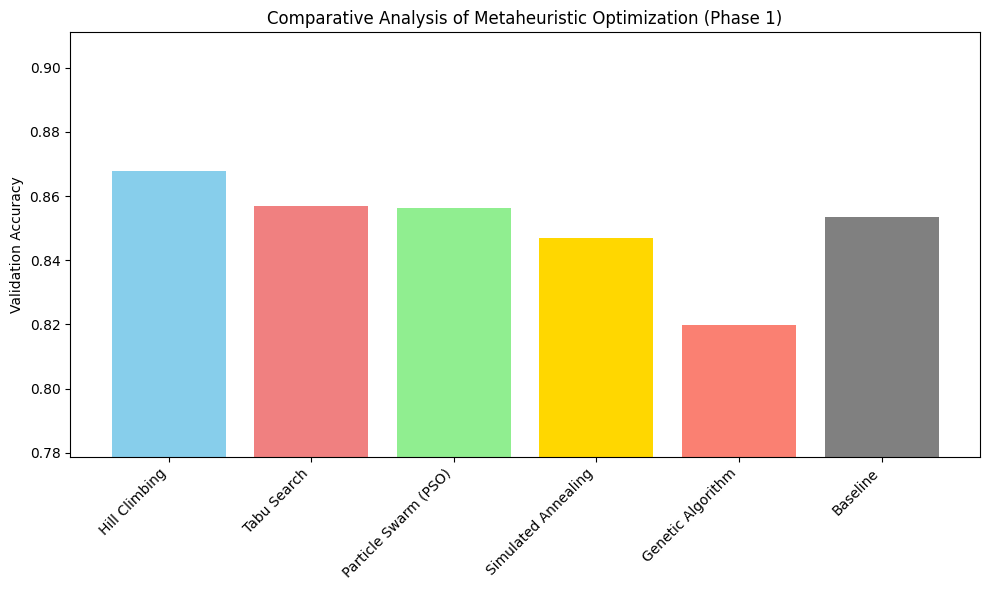

In [ ]:
print("\n--- Comparative Analysis ---")
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Optimal Vocabulary Size (K) found by ACA Proxy: {MAX_WORDS_OPTIMIZED}")
print(f"Estimated Accuracy with K={MAX_WORDS_OPTIMIZED}: {best_acc_aca:.4f}")

print("\n--- Model Parameter Optimization Results ---")
print(f"Hill Climbing: {best_score_hc:.4f}")
print(f"Simulated Annealing: {best_score_sa:.4f}")
print(f"Tabu Search: {best_score_ts:.4f}")
print(f"Genetic Algorithm: {best_score_ga:.4f}")
print(f"Particle Swarm (PSO): {best_score_pso:.4f}")

data = {
    'Algorithm': list(results.keys()),
    'Accuracy': [results[k][0] for k in results.keys()],
    'Time (s)': [results[k][1] for k in results.keys()]
}
df = pd.DataFrame(data).sort_values(by='Accuracy', ascending=False)
df.loc[len(df)] = ['Baseline', baseline_acc, baseline_time]

print("\nDetailed Comparison Table:")
print(df.to_markdown(index=False, floatfmt=".4f"))

plt.figure(figsize=(10, 6))
plt.bar(df['Algorithm'], df['Accuracy'], color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'salmon', 'gray'])
plt.title('Comparative Analysis of Metaheuristic Optimization (Phase 1)')
plt.ylabel('Validation Accuracy')
plt.ylim(min(df['Accuracy']) * 0.95, max(df['Accuracy']) * 1.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('optimization_comparison.png')
plt.show()

# Phase 2

In [ ]:
def vector_to_hparams(vec):
    lstm_units_options = [32, 64, 128, 256]
    dropout_options = [0.1, 0.2, 0.3, 0.4]
    lr_options = [0.01, 0.001, 0.0001]
    lstm_idx = min(3, int(round(vec[0] * 3)))
    drop_idx = min(3, int(round(vec[1] * 3)))
    lr_idx = min(2, int(round(vec[2] * 2)))
    return lstm_units_options[lstm_idx], dropout_options[drop_idx], lr_options[lr_idx]
def objective_function(vec):
    lstm_units, dropout_rate, learning_rate = vector_to_hparams(vec)
    model = create_model(lstm_units, dropout_rate, learning_rate)
    model.fit(X_train_padded, y_train, epochs=METAHEURISTIC_EPOCHS, batch_size=BASELINE_BATCH_SIZE, verbose=0)
    acc = evaluate_model(model, X_test_padded, y_test)
    return acc, lstm_units, dropout_rate, learning_rate

In [ ]:
class FireflyOptimizer:
    def __init__(self, evaluate_fn, n_fireflies=12, max_iter=20,
                 alpha=0.25, beta0=1.0, gamma=1.0,
                 minimize=False, seed=42):

        random.seed(seed)
        np.random.seed(seed)

        self.evaluate_fn = evaluate_fn
        self.n = n_fireflies
        self.max_iter = max_iter
        self.alpha = alpha
        self.beta0 = beta0
        self.gamma = gamma
        self.dim = 3
        self.minimize = minimize

        self.population = np.random.rand(self.n, self.dim)
        self.values = np.full(self.n, -np.inf if not minimize else np.inf)
        self.brightness = np.zeros(self.n)

    @staticmethod
    def distance(a, b):
        return np.linalg.norm(a - b)

    def compute_brightness(self):
        if self.minimize:
            self.brightness = 1 / (1 + self.values)
        else:
            self.brightness = self.values

    def evaluate_population(self):
        print("\n Evaluating Fireflies...")
        for i in range(self.n):
            if not np.isfinite(self.values[i]):
                acc, lstm, drop, lr = self.evaluate_fn(self.population[i])
                self.values[i] = -acc if self.minimize else acc
                print(f"    • Firefly {i}: hparams = (LSTM:{lstm}, Drop:{drop}, LR:{lr:.4f}) → Accuracy = {acc:.4f}")

        self.compute_brightness()

    def run(self):
        self.evaluate_population()

        best_idx = np.argmax(self.values) if not self.minimize else np.argmin(self.values)
        best_val = self.values[best_idx]
        best_vec = self.population[best_idx].copy()
        best_acc = -best_val if self.minimize else best_val
        best_params = vector_to_hparams(best_vec)

        print(f"\nInitial Best Accuracy: {best_acc:.4f} with params {best_params}")

        for iteration in range(self.max_iter):
            print(f"\n=== Firefly Algorithm - Iteration {iteration+1}/{self.max_iter} ===")

            for i in range(self.n):
                moved = False
                for j in range(self.n):
                    if self.brightness[j] > self.brightness[i]:
                        r = self.distance(self.population[i], self.population[j])
                        beta = self.beta0 * math.exp(-self.gamma * r**2)
                        eps = np.random.rand(self.dim) - 0.5
                        move = beta * (self.population[j] - self.population[i]) + self.alpha * eps
                        self.population[i] += move
                        self.population[i] = np.clip(self.population[i], 0, 1)
                        moved = True

                if moved:
                    self.values[i] = float("nan")

            self.evaluate_population()

            current_best_idx = np.argmax(self.values) if not self.minimize else np.argmin(self.values)
            current_best_val = self.values[current_best_idx]
            current_acc = -current_best_val if self.minimize else current_best_val

            if (not self.minimize and current_best_val > best_val) or (self.minimize and current_best_val < best_val):
                best_val = current_best_val
                best_vec = self.population[current_best_idx].copy()
                best_acc = current_acc
                best_params = vector_to_hparams(best_vec)
                print(f"   >>> New Global Best: {best_acc:.4f} with params {best_params}")

            print(f"   Best after iteration {iteration+1}: {best_acc:.4f}")
            self.alpha *= 0.95

        return best_acc, best_params

In [ ]:
print("\n--- Running Firefly Algorithm for Model Parameter Optimization (6th algorithm) ---")
start_time = time.time()
firefly_opt = FireflyOptimizer(objective_function, n_fireflies=10, max_iter=8, minimize=False)
best_score_ff, best_params_ff = firefly_opt.run()
time_ff = time.time() - start_time

lstm_ff, drop_ff, lr_ff = best_params_ff
print_result("Firefly Algorithm", best_score_ff, (lstm_ff, drop_ff, lr_ff), time_ff)
results['Firefly Algorithm'] = (best_score_ff, time_ff)



--- Running Firefly Algorithm for Model Parameter Optimization (6th algorithm) ---

 Evaluating Fireflies...


Argument `input_length` is deprecated. Just remove it.


    • Firefly 0: hparams = (LSTM:64, Drop:0.4, LR:0.0010) → Accuracy = 0.8553
    • Firefly 1: hparams = (LSTM:128, Drop:0.1, LR:0.0100) → Accuracy = 0.8483
    • Firefly 2: hparams = (LSTM:32, Drop:0.4, LR:0.0010) → Accuracy = 0.8656
    • Firefly 3: hparams = (LSTM:128, Drop:0.1, LR:0.0001) → Accuracy = 0.7193
    • Firefly 4: hparams = (LSTM:128, Drop:0.2, LR:0.0100) → Accuracy = 0.8538
    • Firefly 5: hparams = (LSTM:64, Drop:0.2, LR:0.0010) → Accuracy = 0.8723
    • Firefly 6: hparams = (LSTM:64, Drop:0.2, LR:0.0010) → Accuracy = 0.8610
    • Firefly 7: hparams = (LSTM:32, Drop:0.2, LR:0.0010) → Accuracy = 0.8703
    • Firefly 8: hparams = (LSTM:64, Drop:0.3, LR:0.0100) → Accuracy = 0.8316
    • Firefly 9: hparams = (LSTM:128, Drop:0.3, LR:0.0100) → Accuracy = 0.8604

Initial Best Accuracy: 0.8723 with params (64, 0.2, 0.001)

=== Firefly Algorithm - Iteration 1/8 ===

 Evaluating Fireflies...
    • Firefly 0: hparams = (LSTM:64, Drop:0.3, LR:0.0100) → Accuracy = 0.8225
    • Fir

## Comparison between 6 metaheuristic

In [ ]:
print("\nUpdated Model Parameter Optimization Results (6 Metaheuristics):")
data = {
    'Algorithm': list(results.keys()),
    'Accuracy': [results[k][0] for k in results.keys()],
    'Time (s)': [results[k][1] for k in results.keys()]
}
df_opt = pd.DataFrame(data).sort_values(by='Accuracy', ascending=False)
df_opt.loc[len(df_opt)] = ['Baseline', baseline_acc, baseline_time]
print(df_opt.to_markdown(index=False, floatfmt=".4f"))



Updated Model Parameter Optimization Results (6 Metaheuristics):
| Algorithm            |   Accuracy |   Time (s) |
|:---------------------|-----------:|-----------:|
| Firefly Algorithm    |     0.8748 |   700.2254 |
| Hill Climbing        |     0.8677 |   217.9864 |
| Tabu Search          |     0.8570 |   267.5663 |
| Particle Swarm (PSO) |     0.8562 |   429.4086 |
| Simulated Annealing  |     0.8470 |    95.7500 |
| Genetic Algorithm    |     0.8198 |   519.6831 |
| Baseline             |     0.8534 |    20.5408 |


In [ ]:
best_algo_row = df_opt.iloc[0]
best_algo_name = best_algo_row['Algorithm']
if best_algo_name == 'Baseline':
    final_lstm, final_drop, final_lr = 128, 0.2, 0.001
    best_acc_final = baseline_acc
else:
    final_lstm, final_drop, final_lr = best_params_ff
    best_acc_final = best_score_ff

print(f"\nSelected Best Hyperparameters from {best_algo_name}: LSTM={final_lstm}, Dropout={final_drop}, LR={final_lr}")



Selected Best Hyperparameters from Firefly Algorithm: LSTM=64, Dropout=0.2, LR=0.001


In [ ]:
print("\n--- Training Final Optimized Model (10 epochs) ---")
final_model = create_model(lstm_units=final_lstm, dropout_rate=final_drop, learning_rate=final_lr)
final_history = final_model.fit(X_train_padded, y_train,
                                epochs=10,
                                batch_size=BASELINE_BATCH_SIZE,
                                validation_data=(X_test_padded, y_test),
                                verbose=1)

final_acc = final_history.history['val_accuracy'][-1]
print(f"Final Optimized Model Validation Accuracy: {final_acc:.4f}")


creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Particle", list, fitness=creator.FitnessMax, speed=list, best=None, best_fit=creator.FitnessMax())



--- Training Final Optimized Model (10 epochs) ---
Epoch 1/10


Argument `input_length` is deprecated. Just remove it.


196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6876 - loss: 0.5572 - val_accuracy: 0.8694 - val_loss: 0.3124
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8927 - loss: 0.2731 - val_accuracy: 0.8758 - val_loss: 0.3022
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9246 - loss: 0.2013 - val_accuracy: 0.8710 - val_loss: 0.3487
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9240 - loss: 0.1972 - val_accuracy: 0.8667 - val_loss: 0.3769
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9430 - loss: 0.1555 - val_accuracy: 0.8559 - val_loss: 0.5106
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9477 - loss: 0.1429 - val_accuracy: 0.8354 - val_loss: 0.4139
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9544 - loss: 0.1280 - val_accuracy: 0.7972 - val_loss: 0.4664
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9360 - loss: 0.1659 - val_accuracy: 0.815

A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.


## Optamize particle swarm with grey Wolf algorithm

In [ ]:
def pso_objective(c1_c2_w_vec):
    c1, c2, w = c1_c2_w_vec[0], c1_c2_w_vec[1], c1_c2_w_vec[2]

    if not hasattr(creator, "FitnessMax"):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if not hasattr(creator, "Particle"):
        creator.create("Particle", list, fitness=creator.FitnessMax, speed=list, best=None)

    toolbox = base.Toolbox()
    toolbox.register("particle", tools.initRepeat, creator.Particle, lambda: random.random(), n=3)
    toolbox.register("population", tools.initRepeat, list, toolbox.particle)

    def update_particle(particle, best_global):
        for i in range(3):
            r1 = random.random()
            r2 = random.random()
            particle.speed[i] = (w * particle.speed[i] +
                                 c1 * r1 * (particle.best[i] - particle[i]) +
                                 c2 * r2 * (best_global[i] - particle[i]))
            particle[i] += particle.speed[i]
            particle[i] = np.clip(particle[i], 0.0, 1.0)

    def evaluate(ind):
        acc, _, _, _ = objective_function(ind)
        return (acc,)

    toolbox.register("evaluate", evaluate)
    toolbox.register("update", update_particle)

    pop = toolbox.population(n=3)
    for part in pop:
        part.speed = [random.uniform(-0.5, 0.5) for _ in range(3)]
        part.fitness.values = toolbox.evaluate(part)
        part.best = part[:]
        part.best_fitness = creator.FitnessMax()
        part.best_fitness.values = part.fitness.values

    best_global = max(pop, key=lambda p: p.fitness.values[0])
    best_global_vals = best_global[:]

    for gen in range(3):
        for part in pop:
            toolbox.update(part, best_global_vals)
            part.fitness.values = toolbox.evaluate(part)

            if part.fitness > part.best_fitness:
                part.best = part[:]
                part.best_fitness.values = part.fitness.values

            if part.fitness > best_global.fitness:
                best_global = part
                best_global_vals = part[:]

    return best_global.fitness.values[0]



In [ ]:
def gwo_for_pso(pop_size=3, max_iter=3):
    dim = 3
    lb = [0.5, 0.5, 0.4]
    ub = [2.5, 2.5, 0.9]

    positions = np.random.uniform(low=lb, high=ub, size=(pop_size, dim))

    alpha_pos = np.zeros(dim)
    alpha_score = -np.inf
    beta_pos = np.zeros(dim)
    beta_score = -np.inf
    delta_pos = np.zeros(dim)
    delta_score = -np.inf

    for it in range(max_iter):
        a = 2 - it * (2 / max_iter)

        for i in range(pop_size):
            positions[i] = np.clip(positions[i], lb, ub)
            fitness = pso_objective(positions[i])

            if fitness > alpha_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = alpha_score, alpha_pos.copy()
                alpha_score, alpha_pos = fitness, positions[i].copy()
            elif fitness > beta_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = fitness, positions[i].copy()
            elif fitness > delta_score:
                delta_score, delta_pos = fitness, positions[i].copy()

        for i in range(pop_size):
            for j in range(dim):
                r1, r2 = random.random(), random.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha_pos[j] - positions[i][j])
                X1 = alpha_pos[j] - A1 * D_alpha

                r1, r2 = random.random(), random.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta_pos[j] - positions[i][j])
                X2 = beta_pos[j] - A2 * D_beta

                r1, r2 = random.random(), random.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta_pos[j] - positions[i][j])
                X3 = delta_pos[j] - A3 * D_delta

                positions[i][j] = (X1 + X2 + X3) / 3.0

    return alpha_pos, alpha_score


In [ ]:
print("\n--- Tuning PSO parameters (c1, c2, w) using Grey Wolf Optimizer ---")

best_params, tuned_pso_acc = gwo_for_pso(pop_size=3, max_iter=3)

print(
    f"\nTuned PSO parameters:"
    f" c1 = {best_params[0]:.3f},"
    f" c2 = {best_params[1]:.3f},"
    f" w = {best_params[2]:.3f}"
)

print(f"Best PSO accuracy with tuned parameters: {tuned_pso_acc:.4f}")



--- Tuning PSO parameters (c1, c2, w) using Grey Wolf Optimizer ---

Tuned PSO parameters: c1 = 1.691, c2 = 1.443, w = 0.606
Best PSO accuracy with tuned parameters: 0.8680


In [ ]:
best_c1 = best_params[0]
best_c2 = best_params[1]
best_w  = best_params[2]

print(f"\n--- Running Tuned PSO with Fixed Optimized c1, c2, and w ---")
print(
    f"Using tuned parameters:"
    f" c1 = {best_c1:.3f},"
    f" c2 = {best_c2:.3f},"
    f" w = {best_w:.3f}"
)

def model_objective(params):
    lstm_units = int(params['lstm_units'])
    dropout_rate = float(params['dropout_rate'])
    learning_rate = float(params['learning_rate'])

    model = create_model(
        lstm_units=lstm_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )
    model.fit(
        X_train_padded, y_train,
        epochs=METAHEURISTIC_EPOCHS,
        batch_size=BASELINE_BATCH_SIZE,
        verbose=0
    )
    acc = evaluate_model(model, X_test_padded, y_test)
    return acc

param_names = ['lstm_units', 'dropout_rate', 'learning_rate']
bounds = np.array([
    [32, 256],
    [0.1, 0.4],
    [1e-4, 1e-2]
])

pso_tuned = PSO(
    obj_func=model_objective,
    param_names=param_names,
    bounds=bounds,
    n_particles=5,
    max_iter=4,
    w=best_w,
    c1=best_c1,
    c2=best_c2
)

start_time = time.time()
best_params_tuned_pso, best_score_tuned_pso, _ = pso_tuned.optimize()
time_tuned_pso = time.time() - start_time

lstm_best = int(best_params_tuned_pso['lstm_units'])
drop_best = float(best_params_tuned_pso['dropout_rate'])
lr_best   = float(best_params_tuned_pso['learning_rate'])

print_result(
    "Tuned PSO (PSO-GWO)",
    best_score_tuned_pso,
    (lstm_best, drop_best, lr_best),
    time_tuned_pso
)

results['Tuned PSO (PSO-GWO)'] = (best_score_tuned_pso, time_tuned_pso)

best_params_tuned = (lstm_best, drop_best, lr_best)



--- Running Tuned PSO with Fixed Optimized c1, c2, and w ---
Using tuned parameters: c1 = 1.691, c2 = 1.443, w = 0.606

--- Starting Particle Swarm Optimization ---

PSO Iteration 1/4
Particle 0 -> Val_Accuracy = 0.8578
Particle 1 -> Val_Accuracy = 0.7971
Particle 2 -> Val_Accuracy = 0.8136
Particle 3 -> Val_Accuracy = 0.8557
Particle 4 -> Val_Accuracy = 0.8801
PSO Found new best!

PSO Iteration 2/4
Particle 0 -> Val_Accuracy = 0.8559
Particle 1 -> Val_Accuracy = 0.8544
Particle 2 -> Val_Accuracy = 0.6473
Particle 3 -> Val_Accuracy = 0.7902
Particle 4 -> Val_Accuracy = 0.8668

PSO Iteration 3/4
Particle 0 -> Val_Accuracy = 0.8728
Particle 1 -> Val_Accuracy = 0.8391
Particle 2 -> Val_Accuracy = 0.7385
Particle 3 -> Val_Accuracy = 0.8409
Particle 4 -> Val_Accuracy = 0.8720

PSO Iteration 4/4
Particle 0 -> Val_Accuracy = 0.8568
Particle 1 -> Val_Accuracy = 0.7130
Particle 2 -> Val_Accuracy = 0.7408
Particle 3 -> Val_Accuracy = 0.8682
Particle 4 -> Val_Accuracy = 0.6826

PSO finished in 2

In [ ]:
data['Tuned PSO (PSO-GWO)'] = (best_score_tuned_pso, time_tuned_pso)


## Train Final Model

In [ ]:
data_list = []

for algo, (acc, t) in results.items():
    data_list.append([algo, acc, t])

data_list.append(['Baseline', baseline_acc, baseline_time])

df_opt = pd.DataFrame(data_list, columns=['Algorithm', 'Accuracy', 'Time'])
df_opt = df_opt.sort_values(by='Accuracy', ascending=False, ignore_index=True)

print(df_opt.to_markdown(index=False, floatfmt=".4f"))

best_row = df_opt.iloc[0]
best_algo_name = str(best_row['Algorithm']).strip()
best_acc_final = float(best_row['Accuracy'])

if best_algo_name == 'Baseline':
    final_lstm, final_drop, final_lr = 128, 0.2, 0.001
    print(f"\nSelected Best: Baseline (Accuracy: {best_acc_final:.4f})")
else:
    best_params_dict = {
        'Hill Climbing': best_params_hc,
        'Simulated Annealing': best_params_sa,
        'Tabu Search': best_params_ts,
        'Genetic Algorithm': best_params_ga,
        'Particle Swarm (PSO)': [
            best_params_pso['lstm_units'],
            best_params_pso['dropout_rate'],
            best_params_pso['learning_rate']
        ],
        'Tuned PSO (PSO-GWO)': (
            best_params_tuned[0],
            best_params_tuned[1],
            best_params_tuned[2]
        ),
        'Firefly Algorithm': (lstm_ff, drop_ff, lr_ff)
    }

    params = best_params_dict.get(best_algo_name, (128, 0.2, 0.001))
    final_lstm, final_drop, final_lr = params[0], params[1], params[2]

    print(f"\nSelected Best: {best_algo_name} (Accuracy: {best_acc_final:.4f})")
    print(f"Hyperparameters: LSTM={final_lstm}, Dropout={final_drop}, LR={final_lr}")


| Algorithm            |   Accuracy |     Time |
|:---------------------|-----------:|---------:|
| Tuned PSO (PSO-GWO)  |     0.8801 | 292.6787 |
| Firefly Algorithm    |     0.8748 | 700.2254 |
| Hill Climbing        |     0.8677 | 217.9864 |
| Tabu Search          |     0.8570 | 267.5663 |
| Particle Swarm (PSO) |     0.8562 | 429.4086 |
| Baseline             |     0.8534 |  20.5408 |
| Simulated Annealing  |     0.8470 |  95.7500 |
| Genetic Algorithm    |     0.8198 | 519.6831 |

Selected Best: Tuned PSO (PSO-GWO) (Accuracy: 0.8801)
Hyperparameters: LSTM=256, Dropout=0.13711989152939136, LR=0.008078301519074934


In [ ]:
final_model = create_model(lstm_units=final_lstm, dropout_rate=final_drop, learning_rate=final_lr)
final_history = final_model.fit(X_train_padded, y_train,
                                epochs=10,
                                batch_size=BASELINE_BATCH_SIZE,
                                validation_data=(X_test_padded, y_test),
                                verbose=1)


Epoch 1/10


Argument `input_length` is deprecated. Just remove it.


196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.6135 - loss: 0.6499 - val_accuracy: 0.8491 - val_loss: 0.3433
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.8712 - loss: 0.3083 - val_accuracy: 0.8702 - val_loss: 0.3165
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9188 - loss: 0.2083 - val_accuracy: 0.8380 - val_loss: 0.4442
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9408 - loss: 0.1534 - val_accuracy: 0.8594 - val_loss: 0.3755
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9532 - loss: 0.1218 - val_accuracy: 0.8619 - val_loss: 0.4523
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9746 - loss: 0.0720 - val_accuracy: 0.8425 - val_loss: 0.5478
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9761 - loss: 0.0678 - val_accuracy: 0.8449 - val_loss: 0.6040
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9755 - loss: 0.0690 - val_accurac

## XAI hypertuning with HA,SA,GWO,,PSO

In [ ]:
word_index = imdb.get_word_index()
index_word = {v+3: k for k, v in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"

def decode_review(seq):
    return " ".join(index_word.get(i, "?") for i in seq if i != 0)

sample_idx = 5
sample_text = decode_review(X_test[sample_idx])
sample_label = y_test[sample_idx]


In [ ]:
def predict_texts(texts):
    seqs = [[word_index.get(w, 2) for w in t.split()] for t in texts]
    padded = pad_sequences(seqs, maxlen=MAX_LEN)
    probs = final_model.predict(padded)
    probs = np.hstack([1 - probs, probs])
    return probs


In [ ]:
def faithfulness_lime(exp, text):
    words = text.split()
    important = [w for w, _ in exp.as_list()]
    masked = " ".join([w for w in words if w not in important[:5]])
    p1 = predict_texts([text])[0][0]
    p2 = predict_texts([masked])[0][0]
    return abs(p1 - p2)


In [ ]:
def sparsity_lime(exp):
    return 1.0 / len(exp.as_list())


In [ ]:
def stability_lime(params):
    scores = []
    for _ in range(3):
        explainer = LimeTextExplainer(class_names=["neg", "pos"])
        exp = explainer.explain_instance(
            sample_text,
            predict_texts,
            num_features=int(params[0]),
            num_samples=int(params[1])
        )
        scores.append([w for w, _ in exp.as_list()])
    return len(set(scores[0]).intersection(scores[1]).intersection(scores[2])) / max(1, len(scores[0]))


In [ ]:
def lime_objective(params):
    num_features = int(params[0])
    num_samples = int(params[1])

    explainer = LimeTextExplainer(class_names=["neg", "pos"])
    exp = explainer.explain_instance(
        sample_text,
        predict_texts,
        num_features=num_features,
        num_samples=num_samples
    )

    f = faithfulness_lime(exp, sample_text)
    s = sparsity_lime(exp)
    st = stability_lime(params)

    score = 0.5*f + 0.3*st + 0.2*s
    return score


### Hill clmbing

In [ ]:
def hill_climbing_xai(iters=10):
    current = np.array([10, 1000])
    best_score = lime_objective(current)

    for _ in range(iters):
        for i in range(2):
            for d in [-1, 1]:
                neigh = current.copy()
                neigh[i] += d * (5 if i == 0 else 200)
                neigh[0] = np.clip(neigh[0], 5, 20)
                neigh[1] = np.clip(neigh[1], 500, 3000)
                s = lime_objective(neigh)
                if s > best_score:
                    best_score = s
                    current = neigh
    return best_score, current


### Simulated Annealing

In [ ]:
def simulated_annealing_xai(iters=15, T=1.0):
    current = np.array([10, 1000])
    best = current.copy()
    best_score = lime_objective(current)

    for _ in range(iters):
        neigh = current + np.array([
            random.choice([-2,2]),
            random.choice([-200,200])
        ])
        neigh[0] = np.clip(neigh[0], 5, 20)
        neigh[1] = np.clip(neigh[1], 500, 3000)

        s = lime_objective(neigh)
        if s > best_score or random.random() < np.exp((s-best_score)/T):
            current = neigh
            best_score = s
            best = neigh
        T *= 0.9

    return best_score, best


### Grey wolf

In [ ]:
def gwo_xai(iters=10):
    wolves = [np.array([random.randint(5,20), random.randint(500,3000)]) for _ in range(5)]

    for _ in range(iters):
        wolves = sorted(wolves, key=lambda w: lime_objective(w), reverse=True)
        alpha, beta, delta = wolves[:3]

        for i in range(3, len(wolves)):
            wolves[i] = (alpha + beta + delta) // 3
            wolves[i][0] = np.clip(wolves[i][0], 5, 20)
            wolves[i][1] = np.clip(wolves[i][1], 500, 3000)

    best = max(wolves, key=lambda w: lime_objective(w))
    return lime_objective(best), best


### Particle swarm

In [ ]:
def pso_xai(iters=5, n=3):
    pos = [np.array([random.randint(5,20), random.randint(500,3000)]) for _ in range(n)]
    vel = [np.zeros(2) for _ in range(n)]
    pbest = pos.copy()
    pbest_s = [lime_objective(p) for p in pos]
    gbest = pbest[np.argmax(pbest_s)]
    for _ in range(iters):
        for i in range(n):
            r1,r2 = random.random(), random.random()
            vel[i] = 0.5*vel[i] + 1.5*r1*(pbest[i]-pos[i]) + 1.5*r2*(gbest-pos[i])
            pos[i] = pos[i] + vel[i]
            pos[i][0] = np.clip(pos[i][0],5,20)
            pos[i][1] = np.clip(pos[i][1],500,3000)
            s = lime_objective(pos[i])
            if s > pbest_s[i]:
                pbest[i] = pos[i].copy()
                pbest_s[i] = s
        gbest = pbest[np.argmax(pbest_s)]
    return max(pbest_s), gbest


### tuning

In [ ]:
results_xai = {}

results_xai["HC"] = hill_climbing_xai()
results_xai["SA"] = simulated_annealing_xai()
results_xai["GWO"] = gwo_xai()
results_xai["PSO"] = pso_xai()

for k, v in results_xai.items():
    print(k, round(v[0], 4), v[1])


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42

### Top contributing words

In [ ]:
print("\n=== Final LIME Explanation (Optimized Parameters) ===")
best_xai = max(results_xai, key=lambda k: results_xai[k][0])
best_params_xai = results_xai[best_xai][1]
print(f"Best XAI optimizer: {best_xai} → Score: {results_xai[best_xai][0]:.4f}")
print(f"Optimized LIME params: num_features={int(best_params_xai[0])}, num_samples={int(best_params_xai[1])}")

explainer = LimeTextExplainer(class_names=["Negative", "Positive"])
exp = explainer.explain_instance(
    sample_text,
    predict_texts,
    num_features=int(best_params_xai[0]),
    num_samples=int(best_params_xai[1])
)

print("\nTop 15 contributing words:")
for word, weight in exp.as_list()[:15]:
    print(f"{word}: {weight:+.4f}")

exp.save_to_file('lime_explanation.html')
print("LIME explanation saved to 'lime_explanation.html'")



=== Final LIME Explanation (Optimized Parameters) ===
Best XAI optimizer: HC → Score: 0.7108
Optimized LIME params: num_features=10, num_samples=1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Top 15 contributing words:
sirk: +0.3663
zeta: -0.2276
disappointing: -0.1916
optimism: +0.1802
waste: -0.1467
fantastic: +0.1385
wonderful: +0.1253
psyche: +0.1245
bo: -0.0894
news: -0.0845
LIME explanation saved to 'lime_explanation.html'


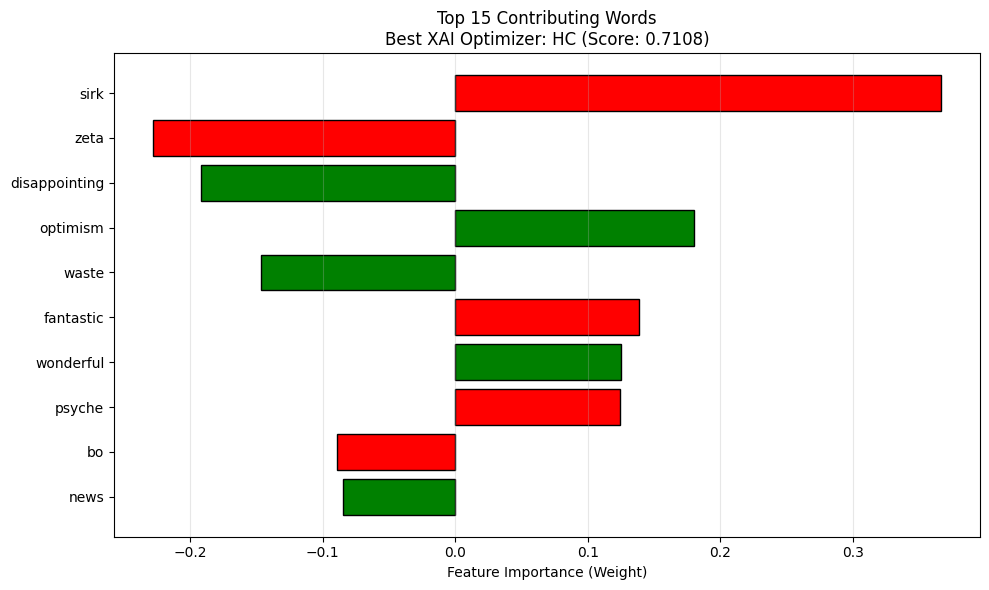

In [ ]:
features = exp.as_list()[:15]
words = [f[0] for f in features]
weights = [f[1] for f in features]
colors = ['green' if w > 0 else 'red' for w in weights]

plt.figure(figsize=(10,6))
plt.barh(words[::-1], weights[::-1], color=colors, edgecolor='black')
plt.xlabel('Feature Importance (Weight)')
plt.title(f'Top 15 Contributing Words\nBest XAI Optimizer: {best_xai} (Score: {results_xai[best_xai][0]:.4f})')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Visulaize XAI results


   COMPARISON OF NUMBER OF FEATURES USED BY EACH ALGORITHM


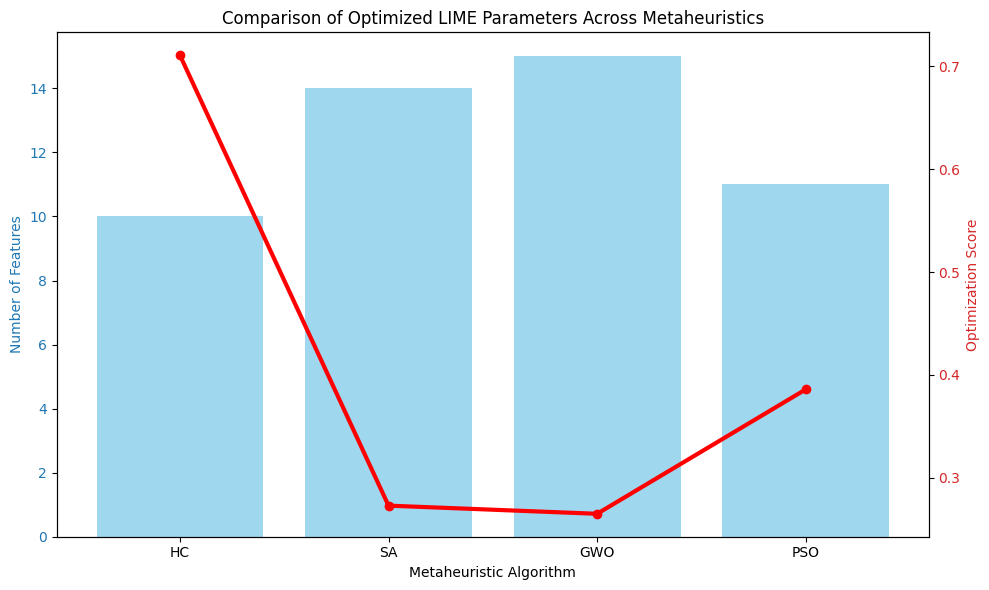

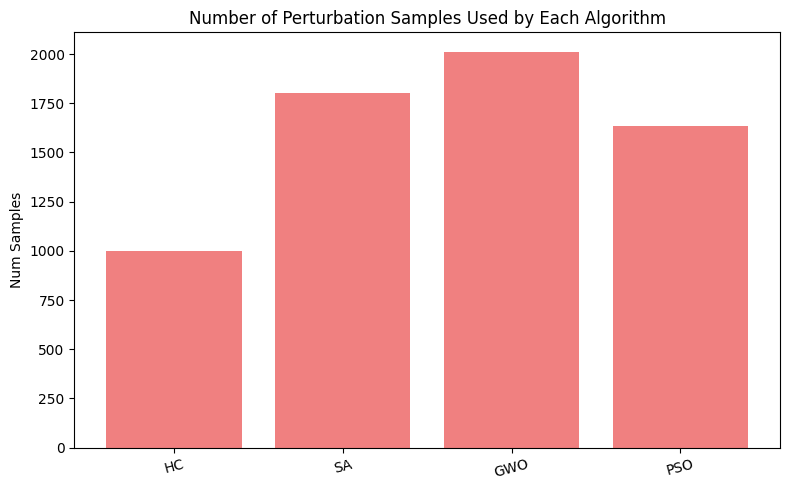

In [ ]:
print("\n" + "="*70)
print("   COMPARISON OF NUMBER OF FEATURES USED BY EACH ALGORITHM")
print("="*70)

algos = list(results_xai.keys())
num_feats = [int(v[1][0]) if isinstance(v[1], (list, np.ndarray)) else int(v[1]) for v in results_xai.values()]
num_samples = [int(v[1][1]) if isinstance(v[1], (list, np.ndarray)) else int(v[1]) for v in results_xai.values()]
scores = [v[0] for v in results_xai.values()]

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Metaheuristic Algorithm')
ax1.set_ylabel('Number of Features', color=color)
bars1 = ax1.bar([a[:15] for a in algos], num_feats, color='skyblue', alpha=0.8, label='Num Features')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Optimization Score', color=color)
bars2 = ax2.plot([a[:15] for a in algos], scores, color='red', marker='o', linewidth=3, label='Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparison of Optimized LIME Parameters Across Metaheuristics')
fig.tight_layout()
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar([a[:15] for a in algos], num_samples, color='lightcoral')
plt.title('Number of Perturbation Samples Used by Each Algorithm')
plt.ylabel('Num Samples')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Test Lime on 3 Samples with for best parameter in each algorithm


           LIME EXPLANATIONS FOR ALL METAHEURISTICS ON 3 SAMPLES

>>> HC (num_features=10, num_samples=1000) <<<
  Sample Index 0 | True: Positive | Predicted: Positive (1.000)


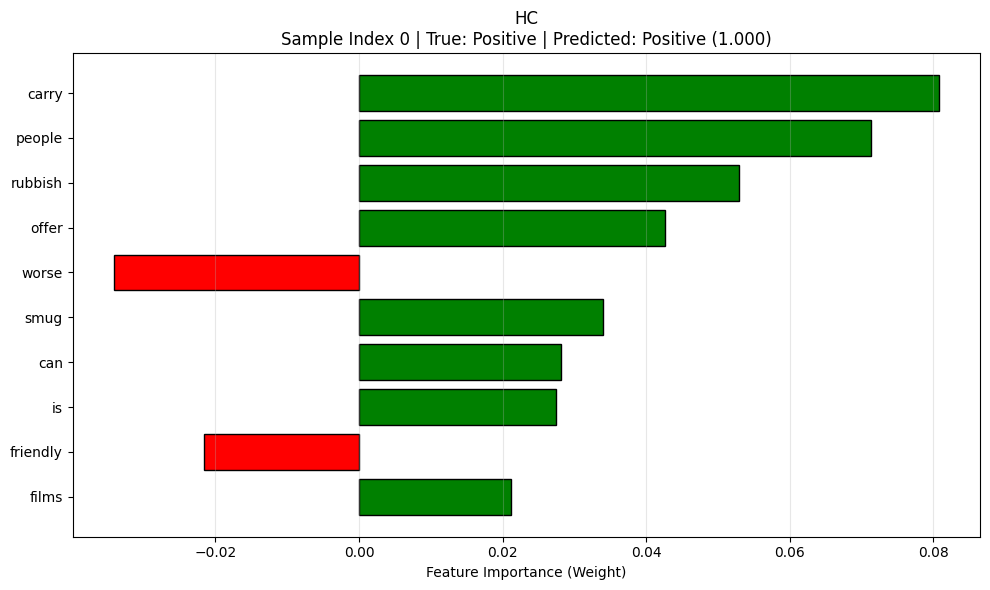

  Sample Index 10 | True: Positive | Predicted: Positive (1.000)


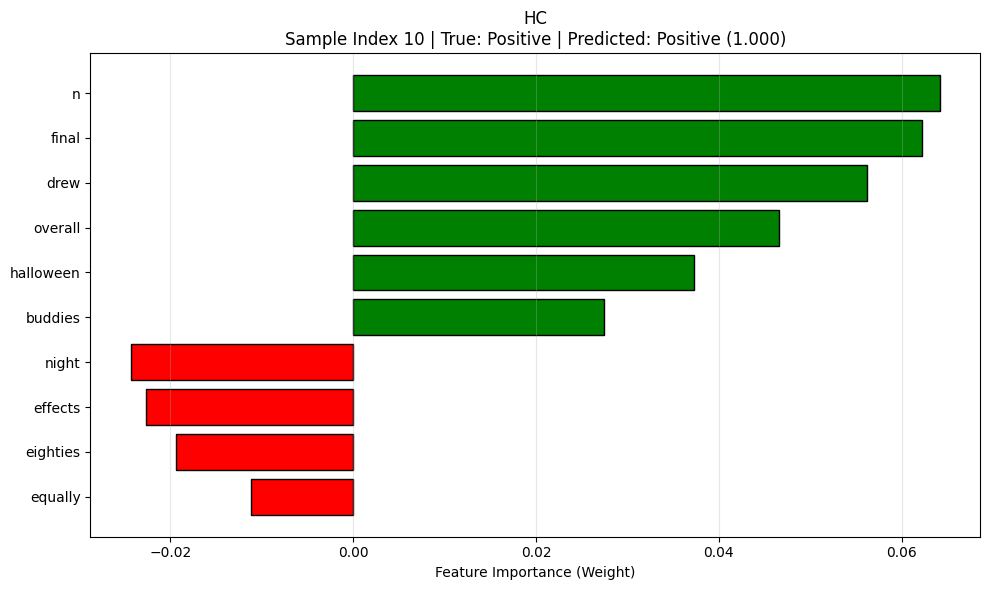

  Sample Index 20 | True: Positive | Predicted: Positive (0.998)


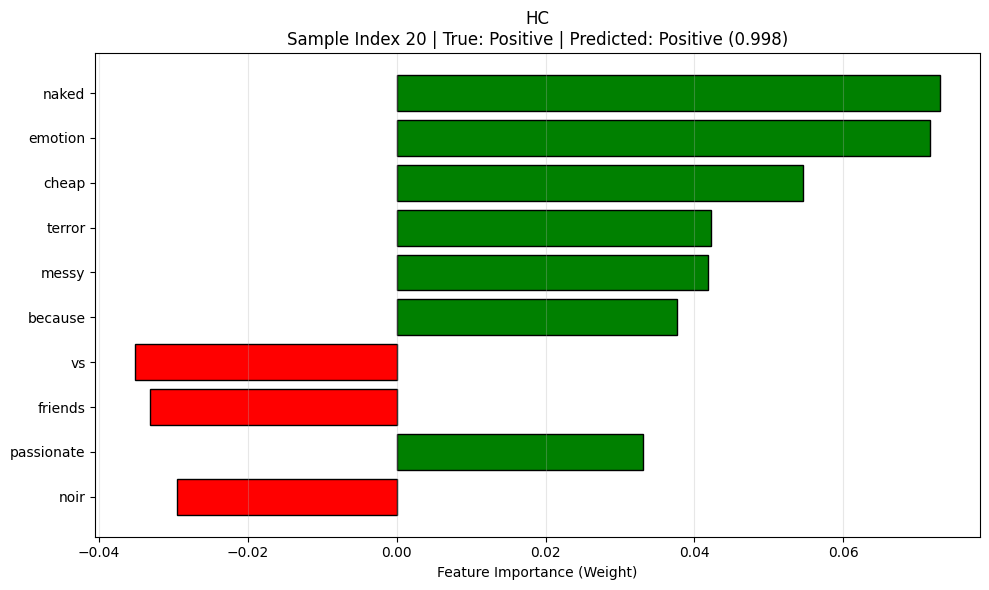


>>> SA (num_features=14, num_samples=1800) <<<
  Sample Index 0 | True: Positive | Predicted: Positive (1.000)


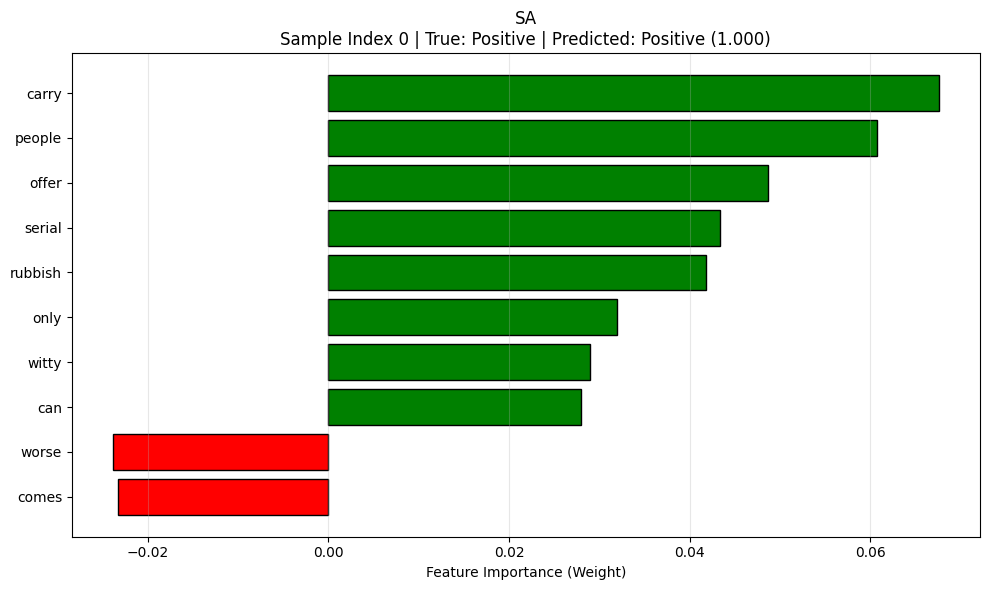

  Sample Index 10 | True: Positive | Predicted: Positive (1.000)


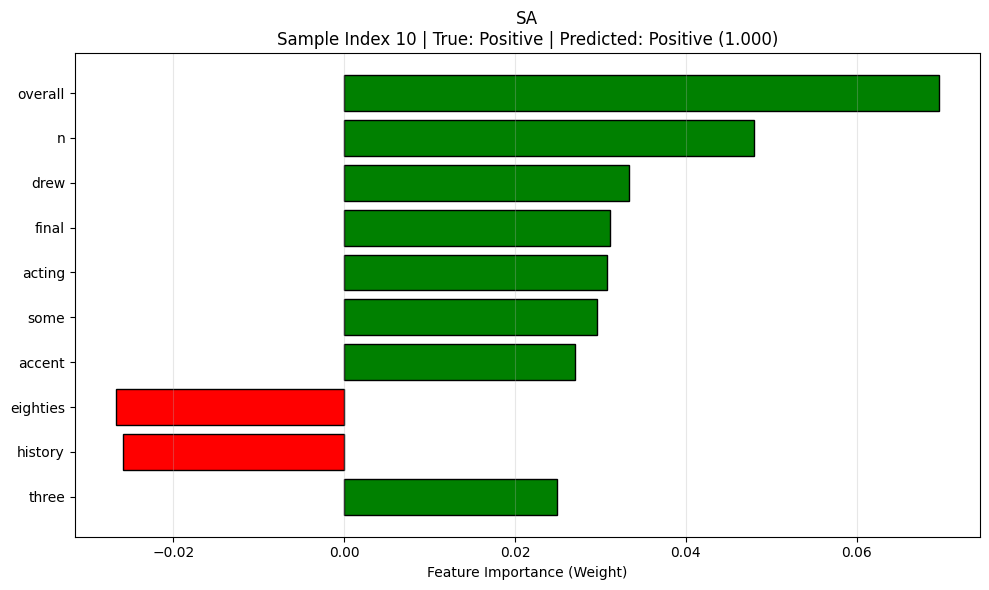

  Sample Index 20 | True: Positive | Predicted: Positive (0.998)


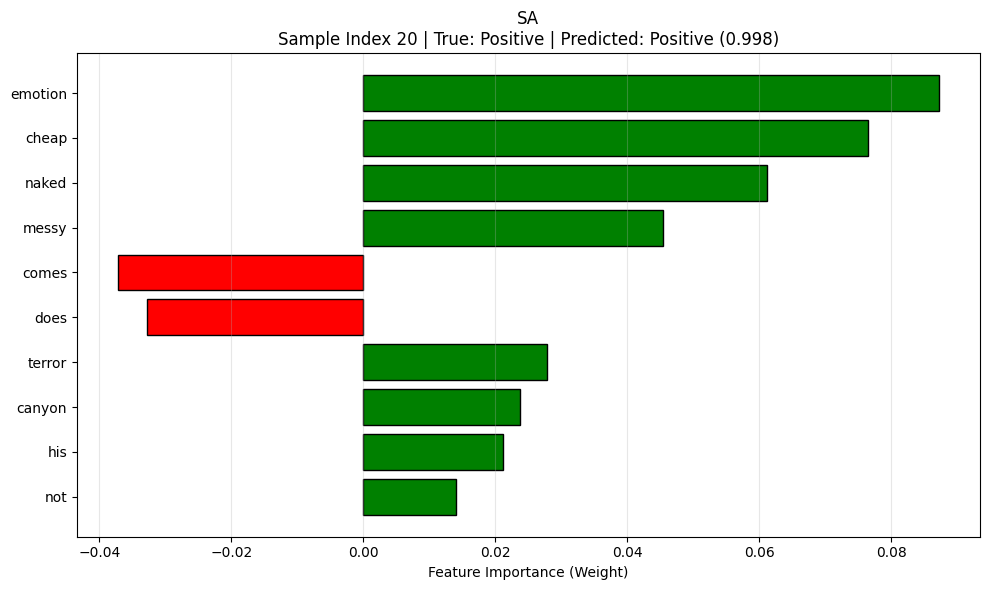


>>> GWO (num_features=15, num_samples=2010) <<<
  Sample Index 0 | True: Positive | Predicted: Positive (1.000)


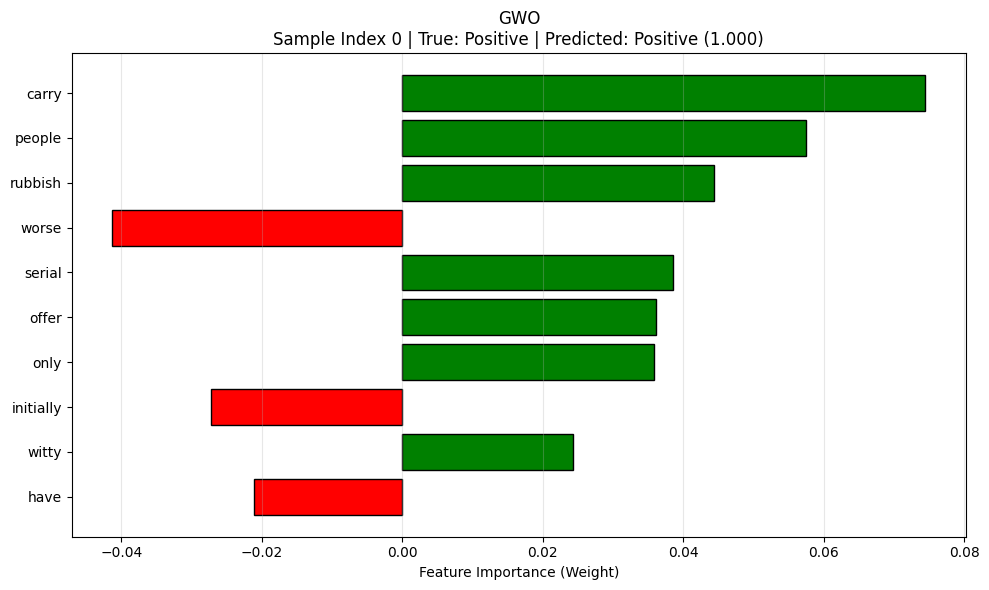

  Sample Index 10 | True: Positive | Predicted: Positive (1.000)


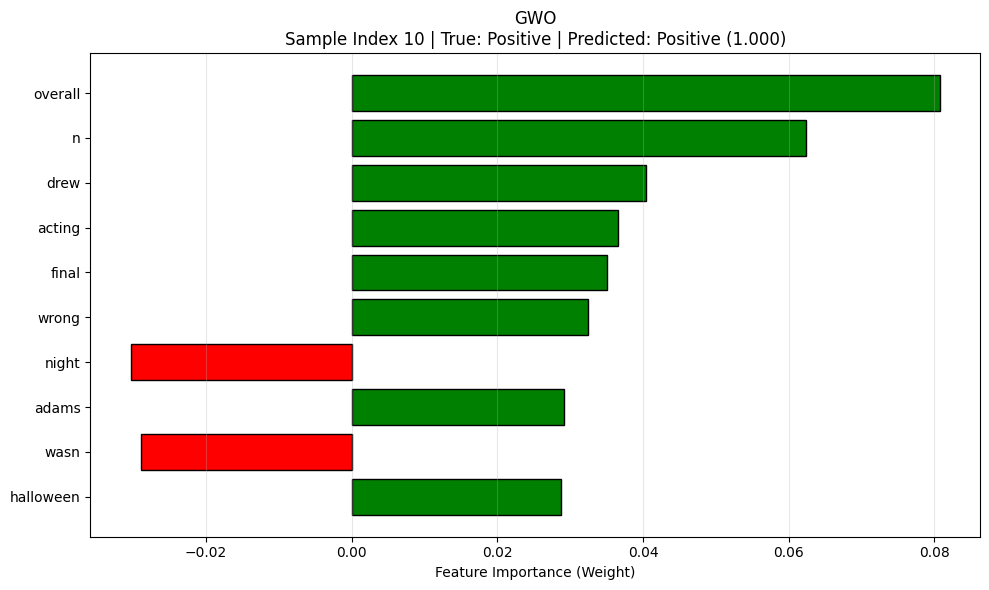

  Sample Index 20 | True: Positive | Predicted: Positive (0.998)


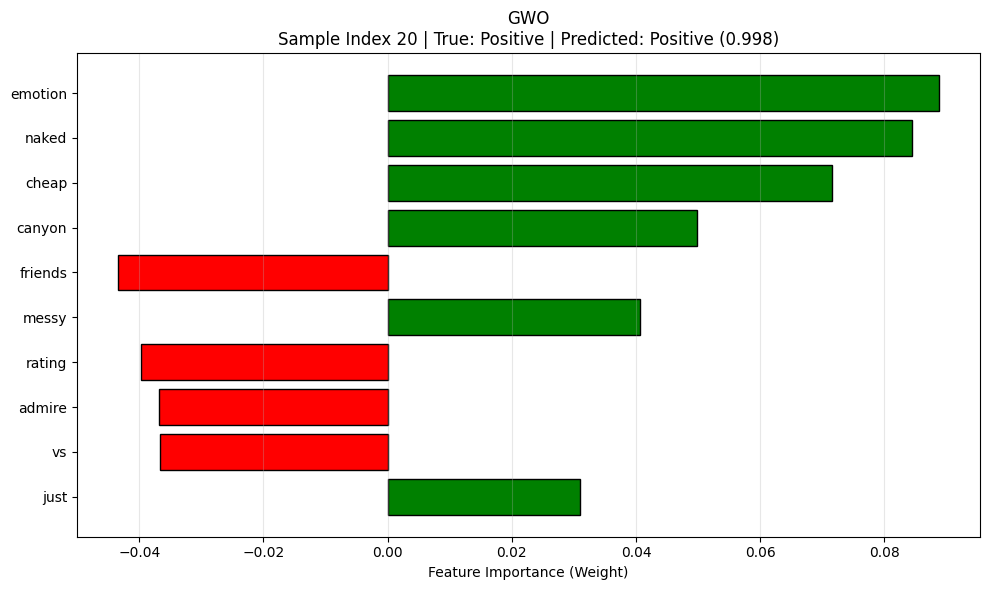


>>> PSO (num_features=11, num_samples=1634) <<<
  Sample Index 0 | True: Positive | Predicted: Positive (1.000)


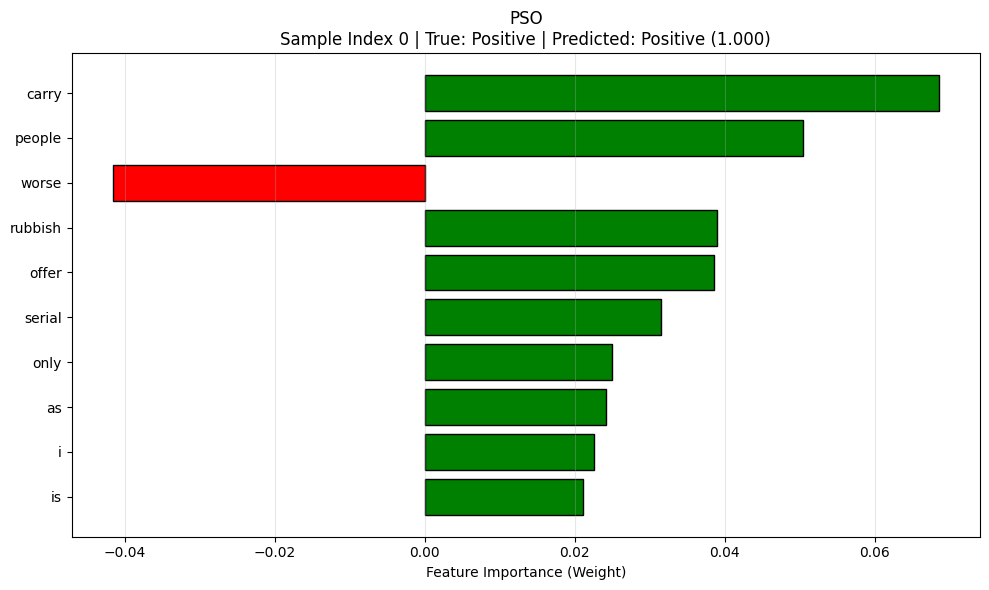

  Sample Index 10 | True: Positive | Predicted: Positive (1.000)


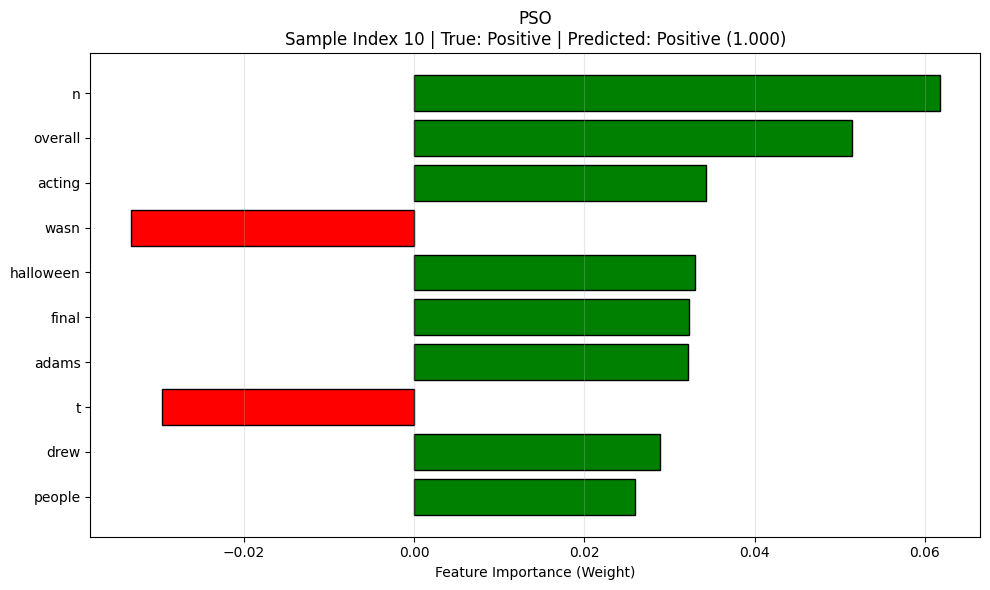

  Sample Index 20 | True: Positive | Predicted: Positive (0.998)


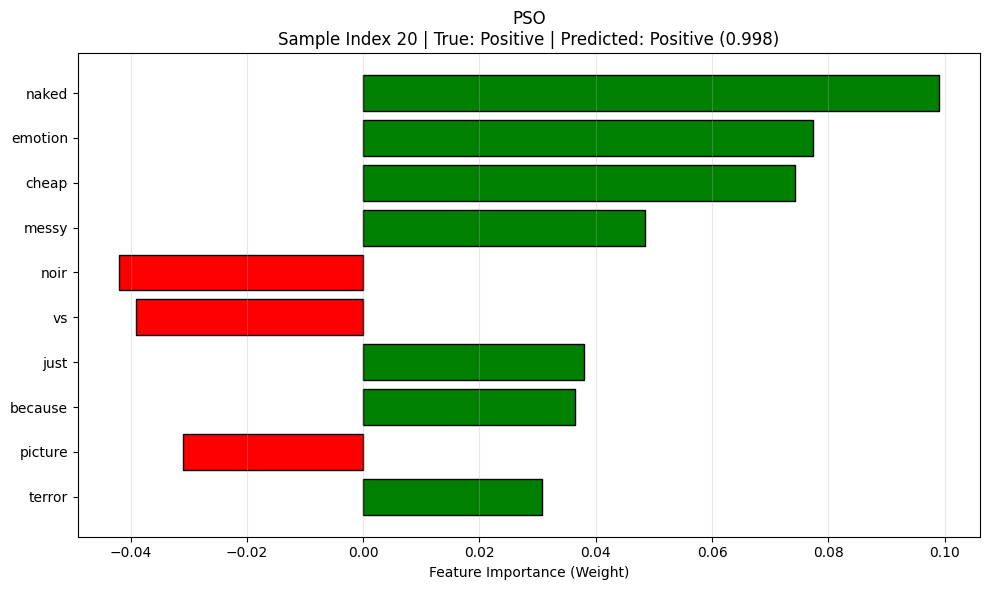

In [ ]:
sample_indices = [0, 10, 20]
explainer = LimeTextExplainer(class_names=["Negative", "Positive"])

def predict_texts(texts):
    seqs = []
    for t in texts:
        seq = [word_index.get(w.lower(), 2) + 3 for w in t.split()]
        seqs.append(seq)
    padded = pad_sequences(seqs, maxlen=MAX_LEN)
    probs = final_model.predict(padded, verbose=0)
    return np.hstack([1 - probs, probs])

def plot_lime_explanation(exp, algo_name, sample_idx, true_label, pred_label, confidence):
    plt.figure(figsize=(10, 6))
    features = exp.as_list()[:10]
    words = [f[0] for f in features]
    weights = [f[1] for f in features]
    colors = ['green' if w > 0 else 'red' for w in weights]
    plt.barh(range(len(words)), weights, color=colors, edgecolor='black')
    plt.yticks(range(len(words)), words)
    plt.xlabel('Feature Importance (Weight)')
    plt.title(f'{algo_name}\nSample Index {sample_idx} | True: {true_label} | Predicted: {pred_label} ({confidence:.3f})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.grid(axis='x', alpha=0.3)
    plt.show()

print("\n" + "="*90)
print("           LIME EXPLANATIONS FOR ALL METAHEURISTICS ON 3 SAMPLES")
print("="*90)

for algo_name, params in results_xai.items():
    num_feat = int(params[1][0]) if isinstance(params[1], (list, np.ndarray)) else int(params[1])
    num_samp = int(params[1][1]) if isinstance(params[1], (list, np.ndarray)) else int(params[1])

    print(f"\n>>> {algo_name} (num_features={num_feat}, num_samples={num_samp}) <<<")

    for idx in sample_indices:
        text = decode_review(X_test[idx])
        true_label_str = "Positive" if y_test[idx] == 1 else "Negative"

        exp = explainer.explain_instance(
            text,
            predict_texts,
            num_features=num_feat,
            num_samples=num_samp
        )

        pred_proba = exp.predict_proba
        pred_label = "Positive" if pred_proba[1] > 0.5 else "Negative"
        confidence = pred_proba[1] if pred_label == "Positive" else pred_proba[0]

        print(f"  Sample Index {idx} | True: {true_label_str} | Predicted: {pred_label} ({confidence:.3f})")

        plot_lime_explanation(exp, algo_name, idx, true_label_str, pred_label, confidence)
